In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


In [5]:
df = pd.read_csv('crop_yield_polynomial_regression.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumn info:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nDescriptive statistics:\n{df.describe()}")


Dataset shape: (500, 5)

Column info:
CropType                         str
Fertilizer_kg_per_hectare    float64
Water_mm_per_season          float64
Pesticide_L_per_hectare      float64
CropYield_tons               float64
dtype: object

Missing values:
CropType                      0
Fertilizer_kg_per_hectare    17
Water_mm_per_season          15
Pesticide_L_per_hectare      12
CropYield_tons                8
dtype: int64

First 5 rows:
  CropType  Fertilizer_kg_per_hectare  Water_mm_per_season  \
0     Corn                      134.7                530.6   
1  Soybean                      108.1                798.5   
2    Wheat                      145.5                822.8   
3    Wheat                      112.2                599.0   
4  Soybean                      179.5                745.8   

   Pesticide_L_per_hectare  CropYield_tons  
0                     5.75            9.17  
1                     6.18            6.44  
2                     8.60            6.41  
3    

# Cleaning

In [6]:
print(f"\nOriginal rows: {len(df)}")

# Remove impossible values 
# Negative physical quantities are impossible
# Fertilizer > 1000 kg/ha in one season is impossible
# Pesticide > 50 L/ha is impossible (toxic spill level)
# Water > 5000 mm in one season is impossible
impossible_mask = (
    (df['Fertilizer_kg_per_hectare'] < 0) |
    (df['Water_mm_per_season'] < 0) |
    (df['Pesticide_L_per_hectare'] < 0) |
    (df['CropYield_tons'] < 0) |
    (df['Fertilizer_kg_per_hectare'] > 1000) |
    (df['Pesticide_L_per_hectare'] > 50) |
    (df['Water_mm_per_season'] > 5000)
)
print(f"Rows with impossible values: {impossible_mask.sum()}")
df_clean = df[~impossible_mask].copy()
print(f"Rows after removing impossible: {len(df_clean)}")


Original rows: 500
Rows with impossible values: 7
Rows after removing impossible: 493


# Medians

In [16]:
# Handle missing values
# For features: median imputation (robust to outliers)
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']:
    df_clean[col ]= df_clean[col].fillna(df_clean[col].median())
    print(f"  {col}: imputed with median = {df_clean[col].median():.2f}")

  Fertilizer_kg_per_hectare: imputed with median = 178.00
  Water_mm_per_season: imputed with median = 713.65
  Pesticide_L_per_hectare: imputed with median = 4.65


In [17]:
# For target: drop rows with missing yield (cannot train without target)
missing_yield = df_clean['CropYield_tons'].isnull().sum()
df_clean = df_clean.dropna(subset=['CropYield_tons'])
print(f"  CropYield_tons: dropped {missing_yield} rows with missing target")

print(f"\nFinal clean dataset: {len(df_clean)} rows")
print(f"Missing values after cleaning:\n{df_clean.isnull().sum()}")

  CropYield_tons: dropped 0 rows with missing target

Final clean dataset: 485 rows
Missing values after cleaning:
CropType                     0
Fertilizer_kg_per_hectare    0
Water_mm_per_season          0
Pesticide_L_per_hectare      0
CropYield_tons               0
dtype: int64


# IQR for Checking Outliers.

In [ ]:
# Outlier detection (IQR method) 
print("\n--- Outlier detection (IQR method) ---")
for col in ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare', 'CropYield_tons']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col}: {outliers} outliers (IQR range: [{lower:.2f}, {upper:.2f}])")



--- Outlier detection (IQR method) ---
  Fertilizer_kg_per_hectare: 8 outliers (IQR range: [28.45, 332.85])
  Water_mm_per_season: 7 outliers (IQR range: [172.75, 1243.55])
  Pesticide_L_per_hectare: 2 outliers (IQR range: [-2.03, 11.36])
  CropYield_tons: 3 outliers (IQR range: [3.65, 11.13])


# Seaborn Visualization for EDA( Exploratory Data Analysis )

Helps in seeing outliers.

/var/folders/ks/sp26_25d5qx2pl5vw8yx56km0000gn/T/ipykernel_8892/911467989.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='CropType', y='CropYield_tons', ax=axes[1,1], palette='Set2')


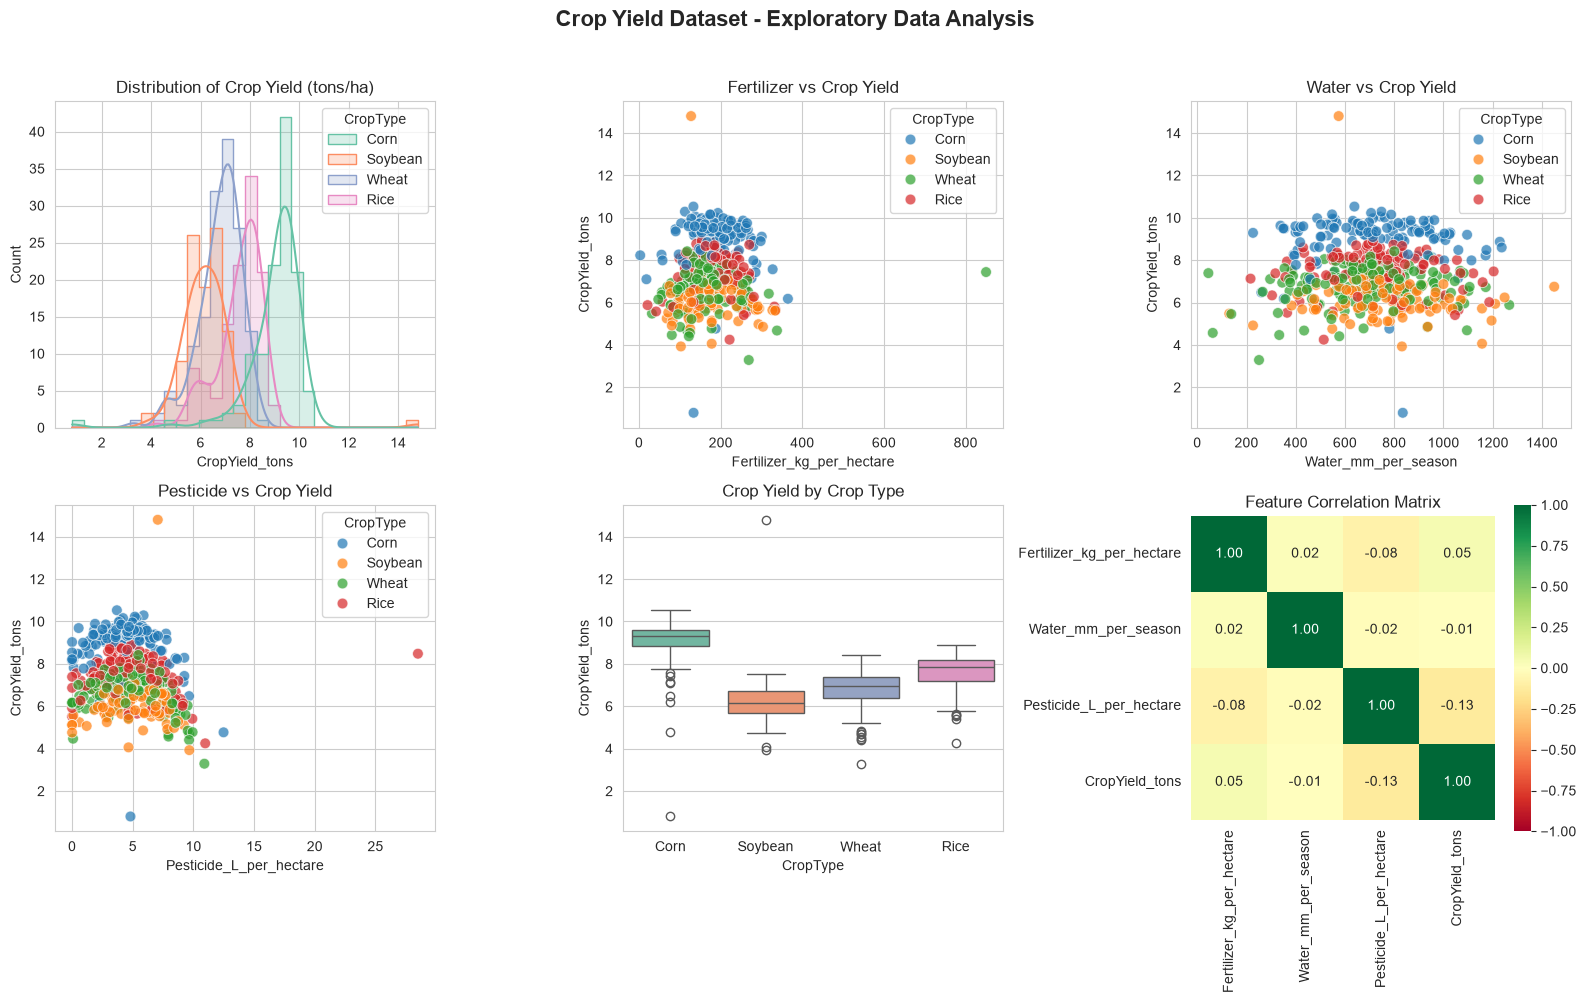

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Crop Yield Dataset - Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Distribution of target
sns.histplot(data=df_clean, x='CropYield_tons' , hue = "CropType", kde=True,element="step", ax=axes[0,0], legend=True, common_norm=False, palette='Set2')
axes[0,0].set_title('Distribution of Crop Yield (tons/ha)')

# Scatter plots
sns.scatterplot(data=df_clean, x='Fertilizer_kg_per_hectare', y='CropYield_tons', 
                hue='CropType', ax=axes[0,1], alpha=0.7, s=60)
axes[0,1].set_title('Fertilizer vs Crop Yield')

sns.scatterplot(data=df_clean, x='Water_mm_per_season', y='CropYield_tons', 
                hue='CropType', ax=axes[0,2], alpha=0.7, s=60)
axes[0,2].set_title('Water vs Crop Yield')

sns.scatterplot(data=df_clean, x='Pesticide_L_per_hectare', y='CropYield_tons', 
                hue='CropType', ax=axes[1,0], alpha=0.7, s=60)
axes[1,0].set_title('Pesticide vs Crop Yield')

# Boxplot by Crop Type
sns.boxplot(data=df_clean, x='CropType', y='CropYield_tons', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Crop Yield by Crop Type')

# Correlation heatmap
numeric_cols = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 
                'Pesticide_L_per_hectare', 'CropYield_tons']
corr = df_clean[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, ax=axes[1,2], 
            square=True, fmt='.2f', vmin=-1, vmax=1)
axes[1,2].set_title('Feature Correlation Matrix')

plt.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()



# Regression with Degree

In [ ]:
X = df_clean[['CropType', 'Fertilizer_kg_per_hectare', 
              'Water_mm_per_season', 'Pesticide_L_per_hectare']]
y = df_clean['CropYield_tons']

In [ ]:

# CELL 5: POLYNOMIAL REGRESSION - DEGREE COMPARISON
# Prepare features
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# Feature groups
numeric_features = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']
categorical_features = ['CropType']

# Store results
results = []

# Test degrees 1 through 5
for degree in range(1, 6):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, 
                                scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores.mean())
    
    n_features = pipeline.named_steps['preprocessor'].transform(X_train).shape[1]
    
    results.append({
        'Degree': degree,
        'Features': n_features,
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'CV_RMSE': cv_rmse
    })
    
    print(f"\nDegree {degree} ({n_features} features):")
    print(f"  Train RMSE: {train_rmse:.3f} | Test RMSE: {test_rmse:.3f}")
    print(f"  Train R²:   {train_r2:.3f} | Test R²:   {test_r2:.3f}")
    print(f"  CV RMSE:    {cv_rmse:.3f}")

results_df = pd.DataFrame(results)
print("\n=== SUMMARY TABLE ===")
print(results_df.to_string(index=False))


# CELL 6: BIAS-VARIANCE TRADEOFF VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Polynomial Regression: Bias-Variance Tradeoff Analysis', 
             fontsize=16, fontweight='bold')

degrees = results_df['Degree'].values

# RMSE vs Degree
axes[0,0].plot(degrees, results_df['Train_RMSE'], 'o-', color='steelblue', 
               linewidth=2, markersize=8, label='Train RMSE')
axes[0,0].plot(degrees, results_df['Test_RMSE'], 's-', color='crimson', 
               linewidth=2, markersize=8, label='Test RMSE')
axes[0,0].set_xlabel('Polynomial Degree')
axes[0,0].set_ylabel('RMSE (tons/ha)')
axes[0,0].set_title('RMSE vs Polynomial Degree')
axes[0,0].legend()
axes[0,0].set_xticks(degrees)

# Annotate best
best_idx = results_df['Test_RMSE'].idxmin()
best_deg = results_df.loc[best_idx, 'Degree']
best_rmse = results_df.loc[best_idx, 'Test_RMSE']
axes[0,0].annotate(f'Best: Degree {int(best_deg)}', 
                   xy=(best_deg, best_rmse), xytext=(best_deg+0.5, best_rmse+0.3),
                   arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
                   fontsize=10, color='green', fontweight='bold')

# R² vs Degree
axes[0,1].plot(degrees, results_df['Train_R2'], 'o-', color='steelblue', 
               linewidth=2, markersize=8, label='Train R²')
axes[0,1].plot(degrees, results_df['Test_R2'], 's-', color='crimson', 
               linewidth=2, markersize=8, label='Test R²')
axes[0,1].set_xlabel('Polynomial Degree')
axes[0,1].set_ylabel('R² Score')
axes[0,1].set_title('R² vs Polynomial Degree')
axes[0,1].legend()
axes[0,1].set_xticks(degrees)
axes[0,1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Feature explosion
axes[1,0].bar(degrees, results_df['Features'], color='mediumpurple', alpha=0.7, edgecolor='black')
axes[1,0].set_xlabel('Polynomial Degree')
axes[1,0].set_ylabel('Number of Features')
axes[1,0].set_title('Feature Explosion with Higher Degrees')
axes[1,0].set_xticks(degrees)
for i, v in enumerate(results_df['Features']):
    axes[1,0].text(degrees[i], v + 1, str(v), ha='center', fontweight='bold')

# Train vs Test gap (overfitting detection)
axes[1,1].bar(degrees - 0.15, results_df['Train_RMSE'], width=0.3, 
              label='Train RMSE', color='steelblue', alpha=0.8)
axes[1,1].bar(degrees + 0.15, results_df['Test_RMSE'], width=0.3, 
              label='Test RMSE', color='crimson', alpha=0.8)
axes[1,1].set_xlabel('Polynomial Degree')
axes[1,1].set_ylabel('RMSE (tons/ha)')
axes[1,1].set_title('Train vs Test RMSE (Overfitting Detection)')
axes[1,1].legend()
axes[1,1].set_xticks(degrees)
axes[1,1].axvspan(3.5, 5.5, alpha=0.1, color='red')
axes[1,1].text(4.5, max(results_df['Test_RMSE'])*0.9, 'OVERFITTING\nZONE', 
               ha='center', fontsize=11, color='darkred', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# CELL 7: ACTUAL vs PREDICTED & RESIDUALS BY DEGREE
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Actual vs Predicted & Residual Plots by Polynomial Degree', 
             fontsize=16, fontweight='bold')

for idx, degree in enumerate(range(1, 6)):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    
    pipeline.fit(X_train, y_train)
    y_test_pred = pipeline.predict(X_test)
    residuals = y_test - y_test_pred
    
    # Actual vs Predicted
    ax1 = axes[0, idx]
    ax1.scatter(y_test, y_test_pred, alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect')
    ax1.set_xlabel('Actual Yield')
    ax1.set_ylabel('Predicted Yield')
    ax1.set_title(f'Degree {degree}')
    ax1.set_xlim(3, 12)
    ax1.set_ylim(3, 12)
    ax1.grid(True, alpha=0.3)
    
    r2 = r2_score(y_test, y_test_pred)
    ax1.text(0.05, 0.95, f'R² = {r2:.3f}', transform=ax1.transAxes, 
             fontsize=10, verticalalignment='top', fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # Residuals
    ax2 = axes[1, idx]
    ax2.scatter(y_test_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
    ax2.axhline(y=0, color='r', linestyle='--', lw=2)
    ax2.set_xlabel('Predicted Yield')
    ax2.set_ylabel('Residuals')
    ax2.set_title(f'Degree {degree} Residuals')
    ax2.grid(True, alpha=0.3)
    
    # Color coding
    if degree >= 4:
        ax1.set_facecolor('#fff0f0')
        ax2.set_facecolor('#fff0f0')
    elif degree == 3:
        ax1.set_facecolor('#f0fff0')
        ax2.set_facecolor('#f0fff0')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# CELL 8: MARGINAL POLYNOMIAL CURVES (Per Feature)
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Polynomial Regression Curves: Feature vs Crop Yield (Marginal)', 
             fontsize=16, fontweight='bold')

features = ['Fertilizer_kg_per_hectare', 'Water_mm_per_season', 'Pesticide_L_per_hectare']
feature_labels = ['Fertilizer (kg/ha)', 'Water (mm/season)', 'Pesticide (L/ha)']
feature_colors = ['forestgreen', 'royalblue', 'darkorange']

for row, (feature, label, color) in enumerate(zip(features, feature_labels, feature_colors)):
    x_vals = df_clean[feature].values.reshape(-1, 1)
    y_vals = df_clean['CropYield_tons'].values
    
    sort_idx = np.argsort(x_vals.flatten())
    x_sorted = x_vals[sort_idx]
    y_sorted = y_vals[sort_idx]
    
    for col, degree in enumerate(range(1, 6)):
        ax = axes[row, col]
        ax.scatter(x_vals, y_vals, alpha=0.4, s=30, color='gray', 
                   edgecolors='black', linewidth=0.3)
        
        poly = PolynomialFeatures(degree=degree)
        x_poly = poly.fit_transform(x_vals)
        model = LinearRegression()
        model.fit(x_poly, y_vals)
        
        x_poly_sorted = poly.transform(x_sorted)
        y_pred_sorted = model.predict(x_poly_sorted)
        
        ax.plot(x_sorted, y_pred_sorted, color=color, linewidth=2.5)
        
        y_pred_all = model.predict(x_poly)
        r2 = r2_score(y_vals, y_pred_all)
        
        ax.set_title(f'{label}\\nDegree {degree} | R² = {r2:.3f}', fontsize=10)
        ax.set_xlabel(label)
        if col == 0:
            ax.set_ylabel('Crop Yield (tons/ha)')
        ax.set_ylim(0, 12)
        ax.grid(True, alpha=0.3)
        
        if degree == 3:
            ax.set_facecolor('#f0fff0')
            for spine in ax.spines.values():
                spine.set_linewidth(2)
                spine.set_color('green')
        elif degree >= 4:
            ax.set_facecolor('#fff0f0')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


# CELL 9: RESPONSE SURFACE COMPARISON (Fertilizer vs Water)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Predicted Crop Yield Response Surface (Fertilizer vs Water)\nPesticide = 4.5 L/ha, Crop = Corn', 
             fontsize=14, fontweight='bold')

fert_range = np.linspace(50, 350, 100)
water_range = np.linspace(200, 1200, 100)
F, W = np.meshgrid(fert_range, water_range)

for idx, degree in enumerate([1, 3, 5]):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('scaler', StandardScaler())
            ]), numeric_features),
            ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
        ]
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    
    grid_df = pd.DataFrame({
        'CropType': ['Corn'] * (100 * 100),
        'Fertilizer_kg_per_hectare': F.flatten(),
        'Water_mm_per_season': W.flatten(),
        'Pesticide_L_per_hectare': [4.5] * (100 * 100)
    })
    
    Z = pipeline.predict(grid_df).reshape(100, 100)
    Z = np.clip(Z, 0, 15)
    
    ax = axes[idx]
    contour = ax.contourf(F, W, Z, levels=20, cmap='YlGn', vmin=4, vmax=12)
    ax.set_xlabel('Fertilizer (kg/ha)')
    ax.set_ylabel('Water (mm/season)')
    
    if degree == 1:
        title = f'Degree {degree} (Linear)\\nUnderfitting'
    elif degree == 3:
        title = f'Degree {degree} (Cubic)\\nOptimal'
        ax.plot(180, 700, 'r*', markersize=15, label='True Optimum')
        ax.legend(loc='lower right')
    else:
        title = f'Degree {degree} (Quintic)\\nOverfitting'
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04, label='Predicted Yield')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()


# CELL 10: FINAL MODEL (Degree 3) - COEFFICIENTS & INTERPRETATION
# Refit best model
best_degree = int(results_df.loc[results_df['Test_RMSE'].idxmin(), 'Degree'])
print(f"Best polynomial degree: {best_degree}")

final_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('regressor', LinearRegression())
])

final_pipeline.fit(X_train, y_train)
final_pred = final_pipeline.predict(X_test)

print(f"\nFinal Model Performance (Degree {best_degree}):")
print(f"  Test RMSE: {np.sqrt(mean_squared_error(y_test, final_pred)):.3f} tons/ha")
print(f"  Test MAE:  {mean_absolute_error(y_test, final_pred):.3f} tons/ha")
print(f"  Test R²:   {r2_score(y_test, final_pred):.3f}")

# Feature names
feature_names = (final_pipeline.named_steps['preprocessor']
                 .get_feature_names_out(['Fertilizer', 'Water', 'Pesticide', 'CropType']))
coefficients = final_pipeline.named_steps['regressor'].coef_
intercept = final_pipeline.named_steps['regressor'].intercept_

print(f"\nIntercept: {intercept:.4f}")
print("\nTop 10 most influential features (by absolute coefficient):")
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
print(coef_df.sort_values('Abs_Coef', ascending=False).head(10).to_string(index=False))